画更好看的training loss和validation loss图

In [ ]:
import  os
current_dir = os.path.dirname(__file__)
print(current_dir)

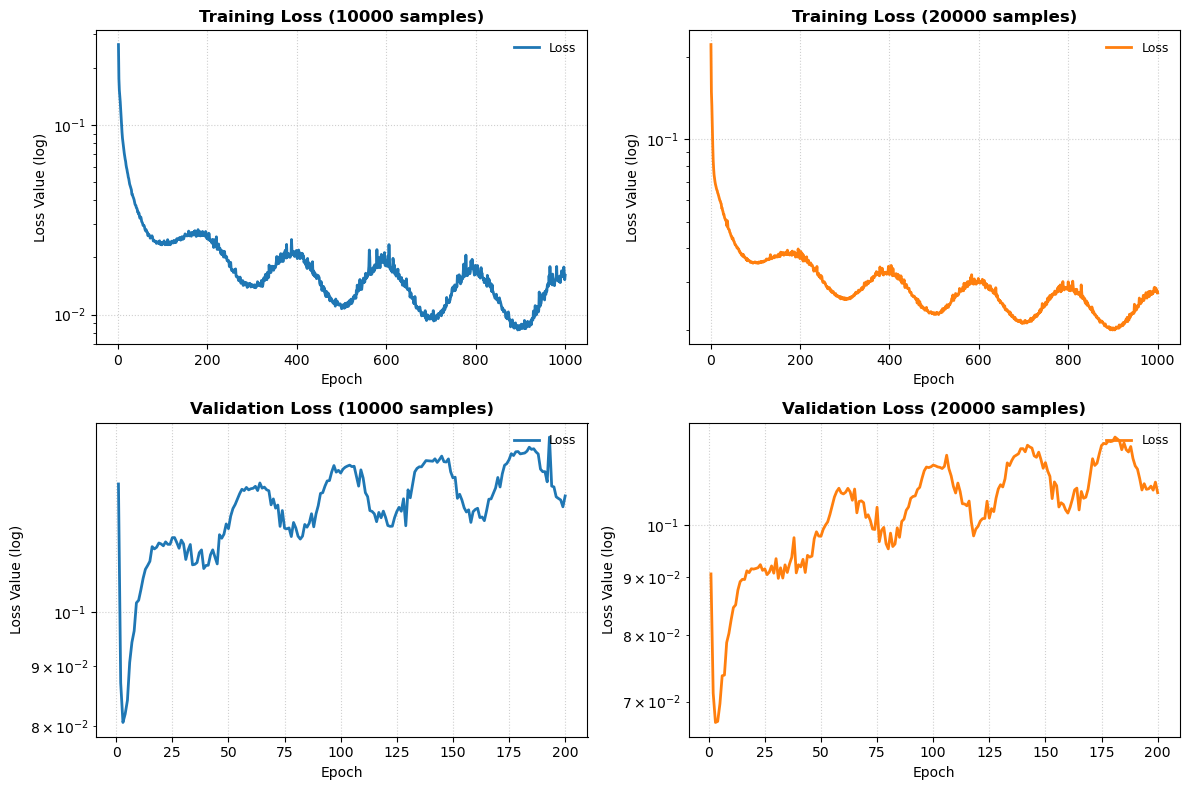

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# ========================= 参数配置 =========================
# 四个txt文件的路径（请按以下顺序修改为实际路径）
current_dir = os.path.dirname(__file__)
train_loss_dir = current_dir + '/train_loss/CosineAnnealingLR_T_max100/lr0.001/'
val_loss_dir = current_dir + '/val_loss/CosineAnnealingLR_T_max100/lr0.001/'
data_type = 'diffusion'
tol_exp = 1000000 # 5 or 1000000
train_loss_file_1 = train_loss_dir + data_type + 'I16N1L4batch256epoch1000d100010000tol' + str(tol_exp) + '_multilevel.txt'   # 第一行左图（训练1）
train_loss_file_2 = train_loss_dir + data_type + 'I16N1L4batch256epoch1000d200020000tol' + str(tol_exp) + '_multilevel.txt'   # 第一行右图（训练2）
val_loss_file_1   = val_loss_dir + data_type + 'I16N1L4batch256epoch1000d100010000tol' + str(tol_exp) + '_multilevel.txt'     # 第二行左图（验证1）
val_loss_file_2   = val_loss_dir + data_type + 'I16N1L4batch256epoch1000d200020000tol' + str(tol_exp) + '_multilevel.txt'     # 第二行右图（验证2）

# 子图标题（可自定义）
titles = [['Training Loss (10000 samples)', 'Training Loss (20000 samples)'],
          ['Validation Loss (10000 samples)', 'Validation Loss (20000 samples)']]

# 是否使用对数Y轴
use_log_scale = True

# 线条颜色（可分别指定四个子图的颜色）
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # 按子图顺序
colors = ['#1f77b4', '#ff7f0e','#1f77b4', '#ff7f0e']  # 按子图顺序

# 线条宽度
line_width = 2

# 是否显示网格
show_grid = True

# 图像尺寸（宽，高），单位英寸
figsize = (12, 8)

# # 保存图片的文件名（可修改）
# save_filename = 'loss_curves_2x2.png'   # 也可改为 .pdf
# dpi = 300

# ========================= 辅助函数：读取txt =========================
def read_loss_file(filepath):
    """读取txt，每行一个loss值，返回numpy数组（loss列表）"""
    losses = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    losses.append(float(line))
                except ValueError:
                    print(f"警告：文件 {filepath} 中存在无法解析的行：{line}")
    if len(losses) == 0:
        raise ValueError(f"文件 {filepath} 无有效数据！")
    return np.array(losses)

# ========================= 读取数据 =========================
data = [
    read_loss_file(train_loss_file_1),
    read_loss_file(train_loss_file_2),
    read_loss_file(val_loss_file_1),
    read_loss_file(val_loss_file_2)
]

# ========================= 构建2x2子图 =========================
fig, axes = plt.subplots(2, 2, figsize=figsize)

# 遍历四个子图
for idx, ax in enumerate(axes.flat):
    losses = data[idx]
    epochs = np.arange(1, len(losses) + 1)   # X轴：epoch/iteration
    
    # 绘制曲线
    ax.plot(epochs, losses, color=colors[idx], linewidth=line_width, label='Loss')
    
    # 设置标题
    row = idx // 2   # 0或1
    col = idx % 2    # 0或1
    ax.set_title(titles[row][col], fontsize=12, fontweight='bold')
    
    # 坐标轴标签
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Loss Value', fontsize=10)
    
    # 对数坐标
    if use_log_scale:
        ax.set_yscale('log')
        ax.set_ylabel('Loss Value (log)', fontsize=10)
    
    # 网格
    if show_grid:
        ax.grid(True, linestyle=':', alpha=0.6)
    
    # 图例
    ax.legend(loc='upper right', frameon=False, fontsize=9)

# 整体调整布局
plt.tight_layout()

# # 保存图片
# plt.savefig(save_filename, dpi=dpi, bbox_inches='tight')
# print(f"图片已保存至：{save_filename}")

# 如需显示（在交互式环境中可取消注释）
plt.show()
plt.close()

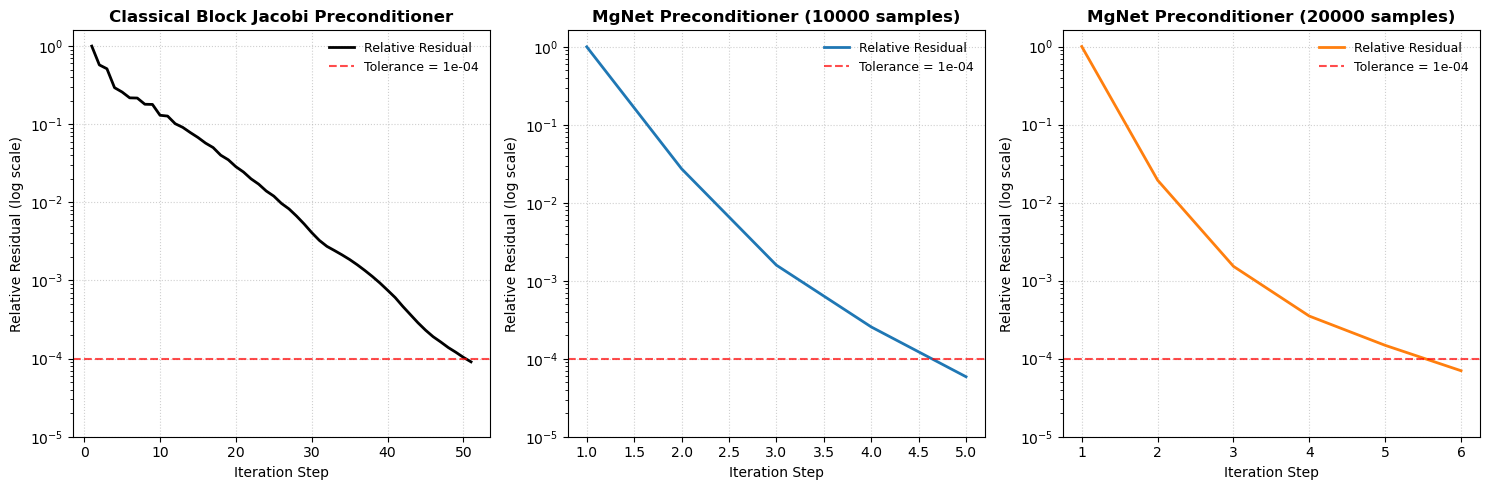

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os


# ========================= 数据输入 =========================
# 请将您的实际数据赋值给以下三个变量
history1 = [1.0, 0.5748264887394252, 0.5129528788364589, 0.2939292716598779, 0.25846177559063693, 0.2176998576393862, 0.21641473073906742, 0.18026097080441403, 0.17926284102562068, 0.13024210144432533, 0.1271969453976076, 0.10158316764531951, 0.09113605714957114, 0.07816375809380416, 0.06770447743172137, 0.0573461646530565, 0.05028647289340675, 0.040166145970375496, 0.035070918625104155, 0.028591737812458846, 0.024464163588265374, 0.019996106945410378, 0.017121095335677093, 0.013981993855026274, 0.012021579145809006, 0.009704885271297556, 0.008245361570653677, 0.006672768177347238, 0.0052865739810275215, 0.004100742510898605, 0.0032624727218075744, 0.0027338619482083987, 0.0024161373186843875, 0.002125765208871805, 0.0018538548904683575, 0.0015889036447389402, 0.0013433479575739996, 0.0011238150626022758, 0.0009260070862844218, 0.0007500700286545225, 0.000604609605760679, 0.00046659256498965054, 0.00036634394406694255, 0.0002878458448757966, 0.00023137367105874692, 0.00019080879739520157, 0.00016334442954253132, 0.0001384711922117348, 0.00012048672011405476, 0.00010366114070292972, 9.084893478962081e-05]
history2 = [1.0, 0.027310645901992746, 0.001585162731682245, 0.0002558871153046725, 5.874634429578969e-05]
history3 = [1.0, 0.019380217905051685, 0.0015254098033065451, 0.000351420541991816, 0.0001482888978059909, 7.01071586790938e-05]

# ========================= 参数配置 =========================
# 子图标题
titles = [
    'Classical Block Jacobi Preconditioner',
    'MgNet Preconditioner (10000 samples)',
    'MgNet Preconditioner (20000 samples)'
]

# 线条颜色
colors = ["#000000",'#1f77b4', '#ff7f0e']

# 线条宽度
line_width = 2

# 是否显示网格
show_grid = True

# 图像尺寸（宽，高），单位英寸
figsize = (15, 5)

# 收敛阈值线（如果有，可以显示一条水平线表示10^-4）
show_tolerance_line = True
tolerance = 1e-4
tolerance_label = f'Tolerance = {tolerance:.0e}'

# # 保存图片的文件名（可修改）
# save_filename = 'gmres_residual_1x3.png'
# dpi = 300

# ========================= 绘图 =========================
fig, axes = plt.subplots(1, 3, figsize=figsize)

# 将所有历史数据放入列表以便遍历
histories = [history1, history2, history3]

for idx, ax in enumerate(axes):
    hist = histories[idx]
    iterations = np.arange(1, len(hist) + 1)   # 迭代步数从1开始
    residuals = np.array(hist)
    
    # 绘制残差曲线
    ax.semilogy(iterations, residuals, color=colors[idx], linewidth=line_width, label='Relative Residual')
    
    # 设置标题
    ax.set_title(titles[idx], fontsize=12, fontweight='bold')
    
    # 坐标轴标签
    ax.set_xlabel('Iteration Step', fontsize=10)
    ax.set_ylabel('Relative Residual (log scale)', fontsize=10)
    
    # 网格
    if show_grid:
        ax.grid(True, linestyle=':', alpha=0.6)
    
    # 添加收敛阈值线
    if show_tolerance_line:
        ax.axhline(y=tolerance, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=tolerance_label)
    
    # 图例
    ax.legend(loc='upper right', frameon=False, fontsize=9)
    
    if len(residuals) > 0:
        # 取残差最小值和 tolerance*0.1 中的较小值作为下限（不能为0）
        y_min = min(min(residuals), tolerance * 0.1)
        # 避免对数为负无穷（如果最小值是0，就给一个很小的正数）
        if y_min <= 0:
            y_min = 1e-8
        ax.set_ylim(bottom=y_min)
    else:
        ax.set_ylim(bottom=tolerance * 0.1)

# 整体调整布局
plt.tight_layout()

# # 保存图片
# plt.savefig(save_filename, dpi=dpi, bbox_inches='tight')
# print(f"图片已保存至：{save_filename}")

# 如需显示（在交互式环境中可取消注释）
plt.show()
plt.close()